nuforc_reports.csv

Performing EDA on the file inside the folder because it contains different data entries and more meaningful insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_1 = pd.read_csv('nuforc_reports.csv')

In [4]:
data_1.head()

,summary,country,city,state,date_time,shape,duration,stats,report_link,text,posted,city_latitude,city_longitude
0,MADAR Node 100,USA,Mountlake Terrace,WA,2019-06-23T18:53:00,NaN,NaN,Occurred : 6/23/2019 18:53 (Entered as : 06/2...,http://www.nuforc.org/webreports/reports/147/S...,MADAR Node 100,2019-06-27T00:00:00,47.794100,-122.306600
1,Steady flashing object with three lights hover...,USA,Hamden,CT,2019-06-23T20:00:00,light,5 hours,Occurred : 6/23/2019 20:00 (Entered as : 6/23...,http://www.nuforc.org/webreports/reports/147/S...,Steady flashing object with three lights hover...,2019-06-27T00:00:00,41.373941,-72.921325
2,"Group of several orange lights, seemingly circ...",USA,Charlottesville,VA,2019-06-20T23:28:00,circle,15 seconds,Occurred : 6/20/2019 23:28 (Entered as : 06/2...,http://www.nuforc.org/webreports/reports/146/S...,"Group of several orange lights, seemingly circ...",2019-06-27T00:00:00,38.055968,-78.494482
3,Dropped in flashed a few times and shot off 5 ...,USA,Lincoln Park,MI,2019-06-21T00:00:00,light,2 minutes,Occurred : 6/21/2019 00:00 (Entered as : 06/2...,http://www.nuforc.org/webreports/reports/146/S...,Dropped in flashed a few times and shot off 5 ...,2019-06-27T00:00:00,42.238500,-83.178300
4,"Location: While traveling in a TGV, from Lille...",France,Douai (France),NaN,2019-06-07T20:00:00,cigar,5 minutes,Occurred : 6/7/2019 20:00 (Entered as : 06/07...,http://www.nuforc.org/webreports/reports/146/S...,"Location: While traveling in a TGV, from Lill...",2019-06-27T00:00:00,NaN,NaN


The shape of the data basically

In [5]:
data_1.shape

(141261, 13)

Printing the types of columns we have 

In [6]:
data_1.dtypes

summary               str
country               str
city                  str
state                 str
date_time             str
shape                 str
duration              str
stats                 str
report_link           str
text                  str
posted                str
city_latitude     float64
city_longitude    float64
dtype: object

Trying to see if there are missing values, if yes then we handle em

In [7]:
missing_values = data_1.isnull().sum()
print(missing_values)

summary              72
country             317
city                482
state              9580
date_time          2660
shape              6299
duration           7619
stats                 0
report_link           0
text                 34
posted             2660
city_latitude     25821
city_longitude    25821
dtype: int64


Duplicate Rows

In [8]:
duplicate_rows = data_1.duplicated().sum()
print(duplicate_rows)

0


Setting the colour palette for the graphs

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'figure.facecolor': '#FFF5F9',      # very light pink canvas
    'axes.facecolor': '#FFF5F9',
    'axes.edgecolor': '#C71585',        # magenta edges
    'axes.grid': True,
    'grid.color': '#F3C6DC',            # soft pink grid lines
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.labelcolor': '#8B0A50',       # deep magenta text
    'xtick.color': '#8B0A50',
    'ytick.color': '#8B0A50',
    'text.color': '#8B0A50',
    'axes.titlecolor': '#8B0A50',
    'font.size': 11,
})

PINK_PALETTE = ['#FF69B4', '#DB7093', '#C71585', '#FF1493', '#D8608F', '#E75480']

converting date time thingies

In [10]:
data_1['date_time_updated'] = pd.to_datetime(data_1['date_time'], errors='coerce')
print(data_1['date_time_updated'].head())

0   2019-06-23 18:53:00
1   2019-06-23 20:00:00
2   2019-06-20 23:28:00
3   2019-06-21 00:00:00
4   2019-06-07 20:00:00
Name: date_time_updated, dtype: datetime64[us]


also checking is there isn't any left out updates of date time

In [11]:
print(data_1['date_time_updated'].isna().sum())

2660


Earliest Sightings

In [12]:
print("Earliest Sighting: ", data_1['date_time_updated'].min())

Earliest Sighting:  1969-01-01 10:00:00


In [13]:
print("Latest Sighting: ", data_1['date_time_updated'].max())

Latest Sighting:  2022-12-22 10:50:00


'Posted' convertion from date time

In [14]:
data_1['posted_updated'] = pd.to_datetime(data_1['posted'], errors='coerce')
print(data_1['posted_updated'].head())

0   2019-06-27
1   2019-06-27
2   2019-06-27
3   2019-06-27
4   2019-06-27
Name: posted_updated, dtype: datetime64[us]


In [15]:
data_1['report_days'] = (data_1['posted_updated'] - data_1['date_time_updated']).dt.days
print(data_1['report_days'].describe())

count    138601.000000
mean        725.353215
std        2337.723523
min       -6924.000000
25%           5.000000
50%          18.000000
75%          64.000000
max       19450.000000
Name: report_days, dtype: float64


visualizing the sighting per year for better understanding 

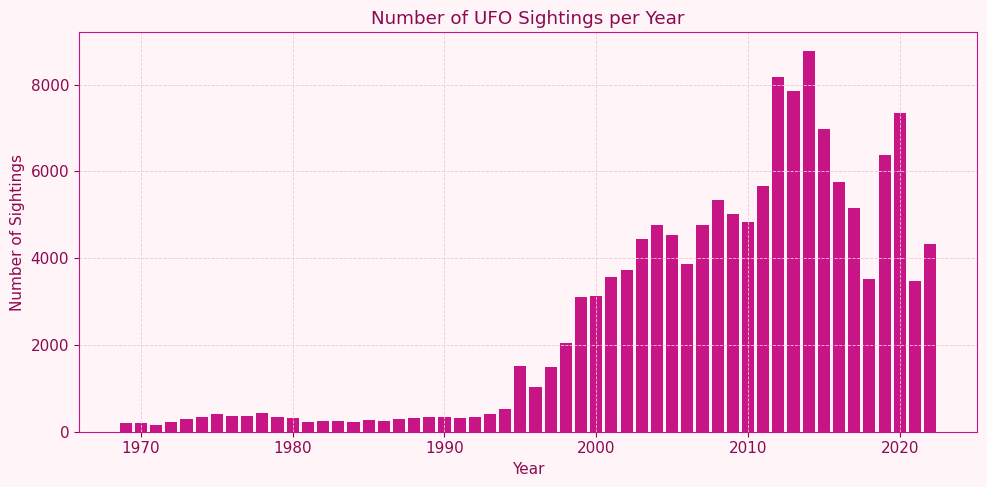

In [16]:
yearly_sightings = data_1['date_time_updated'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_sightings.index, yearly_sightings.values, color=PINK_PALETTE[2])
ax.set_title('Number of UFO Sightings per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Sightings')
plt.tight_layout()
plt.show()

ax is basically an actual plotting area inside that figure

Trying to figure out impact of seasons and time of day on the pattern of sightings

In [17]:
#extracting the time components first
data_1['month'] = data_1['date_time_updated'].dt.month
data_1['day_of_week'] = data_1['date_time_updated'].dt.day_of_week
data_1['hour'] = data_1['date_time_updated'].dt.hour

#Checking sightings by month firstly
monthly_sightings = data_1['month'].value_counts().sort_index()
print("Monthly Sightings: ", monthly_sightings)

Monthly Sightings:  month
1.0      9724
2.0      8158
3.0      9344
4.0      9713
5.0      9792
6.0     13120
7.0     16055
8.0     14436
9.0     13347
10.0    13049
11.0    11705
12.0    10158
Name: count, dtype: int64


In [18]:
#sightings by day of week
weekly_sightings = data_1['day_of_week'].value_counts().sort_index()
print("Weekly Sightings: ", weekly_sightings)

Weekly Sightings:  day_of_week
0.0    17395
1.0    18092
2.0    18663
3.0    19190
4.0    20240
5.0    24620
6.0    20401
Name: count, dtype: int64


In [19]:
#hourly sightings
hourly_sightings = data_1['hour'].value_counts().sort_index()
print("Hourly Sightings: ", hourly_sightings)

Hourly Sightings:  hour
0.0      8618
1.0      5372
2.0      3878
3.0      3571
4.0      2854
5.0      3308
6.0      2680
7.0      1778
8.0      1531
9.0      1816
10.0     2117
11.0     2089
12.0     2390
13.0     2250
14.0     2208
15.0     2438
16.0     2855
17.0     4396
18.0     7193
19.0    10436
20.0    14673
21.0    19421
22.0    17879
23.0    12850
Name: count, dtype: int64


Visualizing them, all three together

In [20]:
#firstly lets rename the days of the week 
days_label = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekly_sightings_labeled = weekly_sightings.rename(index=days_label)

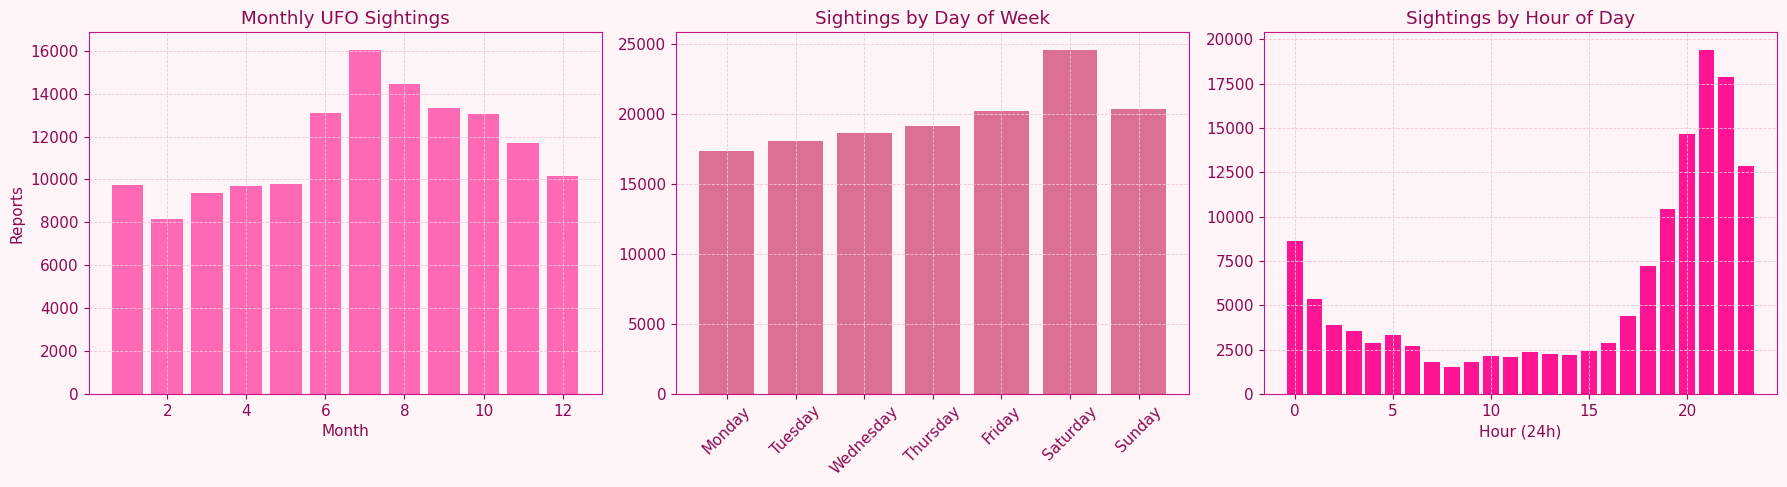

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(monthly_sightings.index, monthly_sightings.values, color=PINK_PALETTE[0])
axes[0].set_title('Monthly UFO Sightings')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Reports')

axes[1].bar(weekly_sightings_labeled.index, weekly_sightings_labeled.values, color=PINK_PALETTE[1])
axes[1].set_title('Sightings by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(hourly_sightings.index, hourly_sightings.values, color=PINK_PALETTE[3])
axes[2].set_title('Sightings by Hour of Day')
axes[2].set_xlabel('Hour (24h)')

plt.tight_layout()
plt.show()

Sightings by the Country 

In [22]:
country_sightings = data_1['country'].value_counts(dropna=False)
print("Top 10 Countries by UFO Sightings: ", country_sightings.head(10))

Top 10 Countries by UFO Sightings:  country
USA               125864
Canada              5701
United Kingdom      3128
Australia            886
India                443
Mexico               388
NaN                  317
Germany              200
New Zealand          197
South Africa         190
Name: count, dtype: int64


State wise distribution of ufo sightings

In [23]:
state_sightings = data_1['state'].value_counts(dropna=False)
print("Top 10 States by UFO Sightings: ", state_sightings.head(10))

Top 10 States by UFO Sightings:  state
CA     15454
NaN     9580
FL      7823
WA      6896
TX      5816
NY      5624
PA      4780
AZ      4727
OH      4271
IL      4112
Name: count, dtype: int64


City wise sightings

In [24]:
city_sightings = data_1['city'].value_counts(dropna=False)
print("Top 10 Cities by UFO Sightings: ", city_sightings.head(10))

Top 10 Cities by UFO Sightings:  city
New York       871
Phoenix        791
Seattle        782
Las Vegas      673
Portland       656
Los Angeles    573
San Diego      565
NaN            482
Houston        476
Tucson         451
Name: count, dtype: int64


Visualizing the relations tgt 

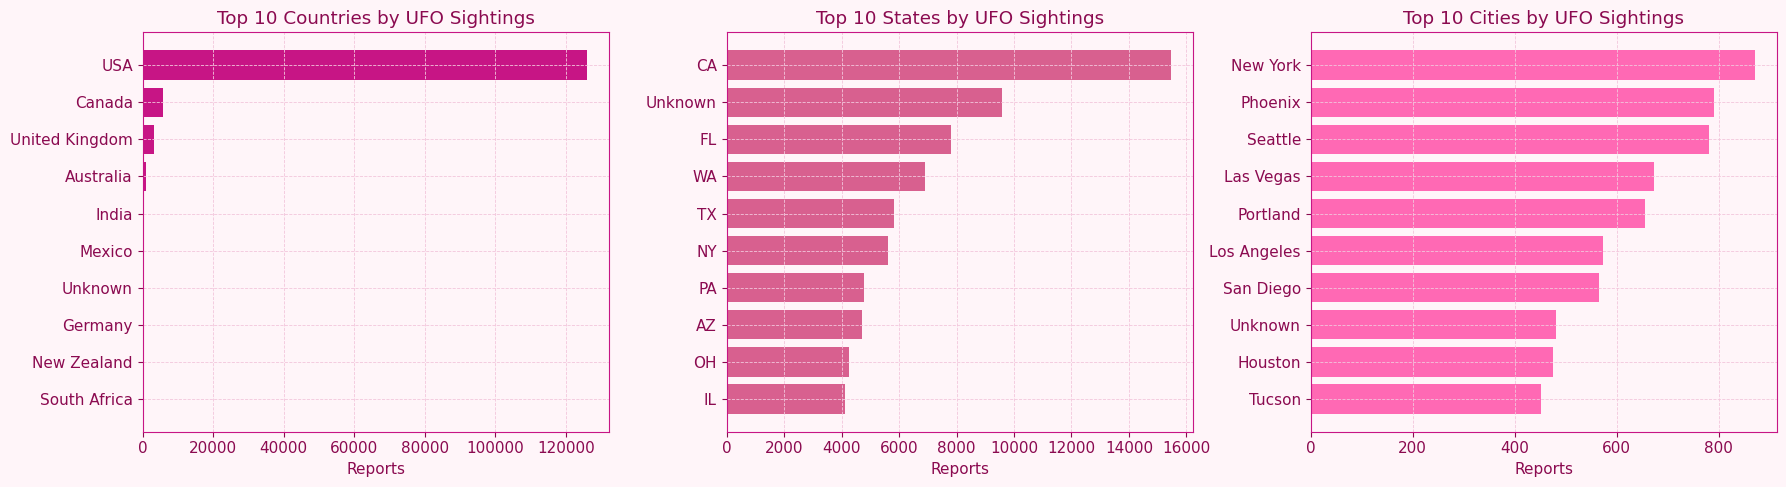

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_countries = country_sightings.head(10)
top_countries.index = top_countries.index.fillna('Unknown').astype(str)

top_states = state_sightings.head(10)
top_states.index = top_states.index.fillna('Unknown').astype(str)

top_cities = city_sightings.head(10)
top_cities.index = top_cities.index.fillna('Unknown').astype(str)

axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=PINK_PALETTE[2])
axes[0].set_title("Top 10 Countries by UFO Sightings")
axes[0].set_xlabel("Reports")

axes[1].barh(top_states.index[::-1], top_states.values[::-1], color=PINK_PALETTE[4])
axes[1].set_title("Top 10 States by UFO Sightings")
axes[1].set_xlabel("Reports")

axes[2].barh(top_cities.index[::-1], top_cities.values[::-1], color=PINK_PALETTE[0])
axes[2].set_title("Top 10 Cities by UFO Sightings")
axes[2].set_xlabel("Reports")

plt.tight_layout()
plt.show()

even though I should have checked this first but we need to check whether the 'Unkown'is a real value in the datatset or not - if not we are good to go warna eh

In [26]:
print("NaN count in State: ", data_1['state'].isna().sum())

NaN count in State:  9580


Checking for State First:

In [27]:
print("Is 'Unknown' Existing?: ")
unknown_count_state = data_1['state'].dropna()[data_1['state'].dropna().str.contains('Unknown', case=False)].value_counts()
print(unknown_count_state.sum())

Is 'Unknown' Existing?: 
0


Check for City Next:

In [28]:
print("NaN count in City: ", data_1['city'].isna().sum())

NaN count in City:  482


In [29]:
print("Is 'Unknown' Existing?: ")
unknown_count_city = data_1['city'].dropna()[data_1['city'].dropna().str.contains('Unknown', case=False)].value_counts()
print(unknown_count_city.sum())

Is 'Unknown' Existing?: 
58


ahh so we see something here, that 58 real reporters said that they don't know where the sighting occured, but the 482 rows have no data at all.

checking the entire latitude and longitude data that we have and can work around for further steps


In [30]:
geo_available = data_1.dropna(subset=['city_latitude', 'city_longitude'])
print("Rows with coordinates: ", f"{len(geo_available)} out of {len(data_1)}")
print("Percentage of rows with coordinates: ", f"{(len(geo_available) / len(data_1)) * 100:.2f}%")

Rows with coordinates:  115440 out of 141261
Percentage of rows with coordinates:  81.72%


Scatter plot construction for a better understanding

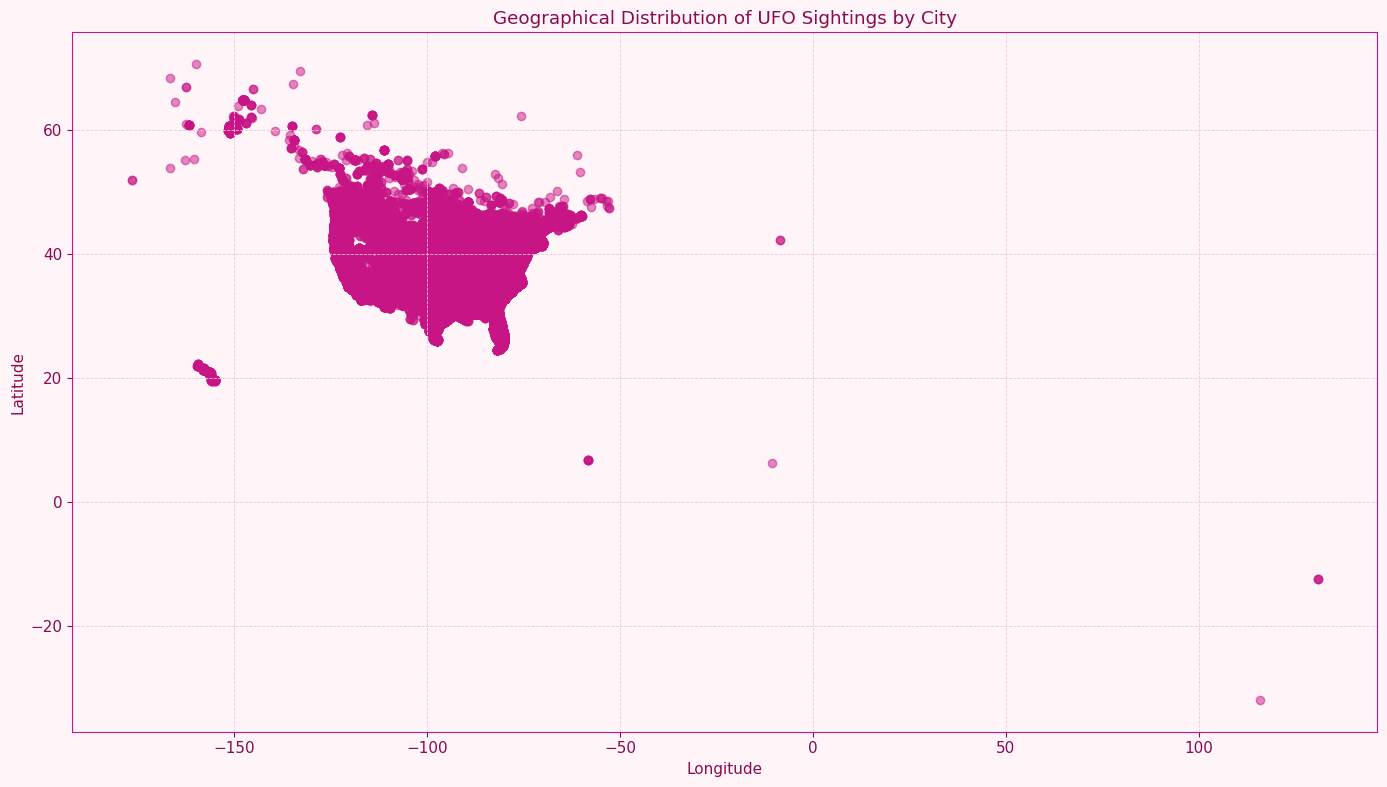

In [31]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(geo_available['city_longitude'], geo_available['city_latitude'], alpha=0.5, color=PINK_PALETTE[2])
ax.set_title('Geographical Distribution of UFO Sightings by City')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

This scatter plot itself tells us that USA is dominating in the sightings

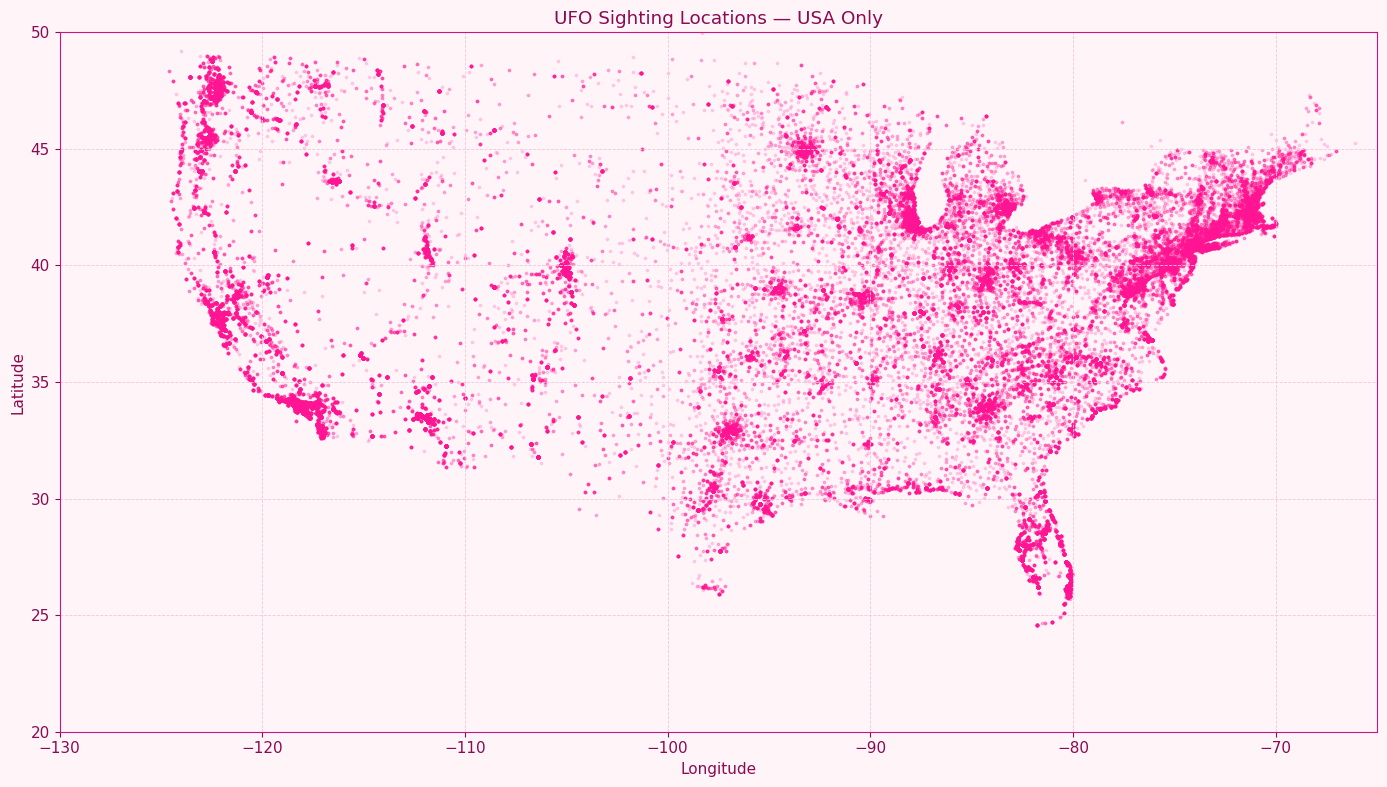

In [32]:
#same plot but it is zoomed in to get a better understandings of what states are involved
fig, ax = plt.subplots(figsize=(14, 8))
usa_geo = geo_available[geo_available['country'] == 'USA']
ax.scatter(usa_geo['city_longitude'], usa_geo['city_latitude'],
           s=3, alpha=0.15, color=PINK_PALETTE[3])
ax.set_xlim(-130, -65)
ax.set_ylim(20, 50)
ax.set_title('UFO Sighting Locations — USA Only')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [33]:
#checking for raw data that can cause us trouble
print("Raw Data (which might be problematic): ", data_1['duration'].dropna().sample(20, random_state=1).to_list())

Raw Data (which might be problematic):  ['3-4 seconds', '30 minutes', '15', '2min', '5 seconds', '30-45 seconds', '7 minutes', '30 seconds', 'seconds', '40min.', '50 seconds', '4 seconds', '15 minutes', 'All Night', '5 minutes', '15 minutes', '10 secs', 'Approx. 1 Min.', '10 minutes', 'one minute or less']


In [34]:
#checking for not null
print("Not Null: ", data_1['duration'].notna().sum())

Not Null:  133642


In [35]:
#number of the unique durations
print("Unique Durations: ", data_1['duration'].nunique())

Unique Durations:  14008


Before we actually write into these 14000 something parameteres we need to figure out how to shape them

In [36]:
import re

def classify_duration(val):
    if pd.isna(val):
        return 'missing'
    val = str(val).strip().lower()
    if re.match(r'^\d+$', val):
        return 'bare_number'                          
    if re.search(r'\d+\s*-\s*\d+', val):
        return 'range'                                
    if re.search(r'\d+\.?\d*\s*(sec|second)', val):
        return 'seconds'
    if re.search(r'\d+\.?\d*\s*(min|minute)', val):
        return 'minutes'
    if re.search(r'\d+\.?\d*\s*(hour|hr)', val):
        return 'hours'
    if re.search(r'^[a-z\s]+$', val):
        return 'unit_only_no_number'                  
    return 'other_unparsed'

data_1['duration_category'] = data_1['duration'].apply(classify_duration)

print(data_1['duration_category'].value_counts())

print("Sample of unparsed entries:")
print(data_1[data_1['duration_category']=='other_unparsed']['duration'].dropna().sample(15, random_state=1).tolist())

duration_category
minutes                66459
seconds                30251
range                  14810
unit_only_no_number     9054
missing                 7619
hours                   6740
other_unparsed          4871
bare_number             1457
Name: count, dtype: int64
Sample of unparsed entries:
['00:01:15', '00:00', '09:55', '21:45', '-', 'An hour or 2?', '23:20', '5:00', '5 mnutes', '20mts', '17:30', 'Ongoing (at 7:05am)', '1+ hr', '45” that I watched', '2:00']


See the unparsed entries are the problem. We need to transform them into clock format too

In [37]:
def classify_duration_v2(val):
    if pd.isna(val):
        return 'missing'
    val = str(val).strip().lower()
    if re.match(r'^\d{1,2}:\d{2}(:\d{2})?$', val):
        return 'clock_format'                         
    if re.match(r'^\d+$', val):
        return 'bare_number'
    if re.search(r'\d+\s*-\s*\d+', val):
        return 'range'
    if re.search(r'\d+\.?\d*\s*(sec|second)', val):
        return 'seconds'
    if re.search(r'\d+\.?\d*\s*(min|minute|mts|mnute)', val):
        return 'minutes'
    if re.search(r'\d+\.?\d*\s*(hour|hr)', val):
        return 'hours'
    if re.search(r'^[a-z\s]+$', val):
        return 'unit_only_no_number'
    return 'other_unparsed'

data_1['duration_category'] = data_1['duration'].apply(classify_duration_v2)
print(data_1['duration_category'].value_counts())

still_unparsed = data_1[data_1['duration_category']=='other_unparsed']['duration'].dropna()
print(f"\nStill unparsed: {len(still_unparsed)}")
print(still_unparsed.sample(min(20, len(still_unparsed)), random_state=1).tolist())

duration_category
minutes                66468
seconds                30251
range                  14810
unit_only_no_number     9054
missing                 7619
hours                   6740
other_unparsed          3327
clock_format            1535
bare_number             1457
Name: count, dtype: int64

Still unparsed: 3327
['2+ hours', 'na.', '18:15 to 19:00', '15+ minutes', '12.00AM to 4PM', '30s', '3: mins', '30+ minutes', 'Nighttime, before 10pm es', 'Since 12:30am', '15+ minutes', '.10', 'an hour and 1/2', '????', '2 nights (16th)', '10.00pm to 2.00 am', 'South jan-march 2019', '4+ minutes', '8+ Seconds', '1.5']


still some 3327 are unparsed


In [38]:
def classify_duration_v3(val):
    if pd.isna(val):
        return 'missing'
    val = str(val).strip().lower()
    if re.match(r'^\d{1,2}:\d{2}(:\d{2})?$', val):
        return 'clock_format'
    if re.search(r'\d+\s+to\s+\d+', val) or re.search(r'\d+(am|pm).*\d+(am|pm)', val):
        return 'time_range'                               
    if re.match(r'^\d+\+?\s*$', val):
        return 'bare_number'                                
    if re.match(r'^\.?\d+\.?\d*$', val):
        return 'bare_number'                                
    if re.search(r'\d+\s*-\s*\d+', val):
        return 'range'
    if re.search(r'\d+\.?\d*\+?\s*(sec|second|s\b)', val):
        return 'seconds'                                    
    if re.search(r'\d+\.?\d*\+?\s*(min|minute|mts|mnute)', val):
        return 'minutes'                                     
    if re.search(r'\d+\.?\d*\+?\s*(hour|hr)', val):
        return 'hours'                                       
    if re.search(r'^[a-z\s]+$', val):
        return 'unit_only_no_number'
    return 'other_unparsed'

data_1['duration_category'] = data_1['duration'].apply(classify_duration_v3)
print(data_1['duration_category'].value_counts())

still_unparsed = data_1[data_1['duration_category']=='other_unparsed']['duration'].dropna()
print(f"\nStill unparsed: {len(still_unparsed)} ({still_unparsed.shape[0]/len(data_1)*100:.2f}% of total data)")

duration_category
minutes                66109
seconds                29838
range                  14808
unit_only_no_number     9054
missing                 7619
hours                   6892
other_unparsed          2326
bare_number             1695
clock_format            1535
time_range              1385
Name: count, dtype: int64

Still unparsed: 2326 (1.65% of total data)


I mean now we have reached the percentage where we can leave some edge cases too because its very less percent but lets see


In [39]:
def parse_duration_to_seconds(row):
    val = row['duration']
    cat = row['duration_category']
    
    if pd.isna(val) or cat in ['missing', 'unit_only_no_number', 'other_unparsed', 'time_range']:
        return np.nan
    
    val = str(val).strip().lower()
    
    num_match = re.search(r'(\d+\.?\d*)', val)
    if not num_match:
        return np.nan
    number = float(num_match.group(1))
    
    if cat == 'seconds':
        return number
    elif cat == 'minutes':
        return number * 60
    elif cat == 'hours':
        return number * 3600
    elif cat == 'bare_number':
        return number
    elif cat == 'range':
        nums = [float(n) for n in re.findall(r'\d+\.?\d*', val)]
        avg = sum(nums) / len(nums) if nums else np.nan
        if re.search(r'(min|minute)', val):
            return avg * 60
        elif re.search(r'(hour|hr)', val):
            return avg * 3600
        else:
            return avg  
    elif cat == 'clock_format':
        parts = val.split(':')
        if len(parts) == 2:  
            return int(parts[0]) * 60 + int(parts[1])
        elif len(parts) == 3: 
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
    return np.nan

data_1['duration_seconds'] = data_1.apply(parse_duration_to_seconds, axis=1)

print("Successfully converted:", data_1['duration_seconds'].notna().sum())
print("Still missing/unconverted:", data_1['duration_seconds'].isna().sum())
print()
print(data_1['duration_seconds'].describe())

Successfully converted: 120877
Still missing/unconverted: 20384

count    1.208770e+05
mean     1.686994e+03
std      2.402720e+05
min      0.000000e+00
25%      3.000000e+01
50%      1.800000e+02
75%      6.000000e+02
max      8.280000e+07
Name: duration_seconds, dtype: float64


Checking the extreme outliers to understand the possible problems

In [40]:
outliers = data_1[data_1['duration_seconds'] > 3600*24].sort_values('duration_seconds', ascending=False)
print(f"Rows with duration > 1 day: {len(outliers)}")
print(outliers[['duration', 'duration_category', 'duration_seconds']].head(20))

print("Under 1 hour:", (data_1['duration_seconds'] <= 3600).sum())
print("1 hour - 1 day:", ((data_1['duration_seconds'] > 3600) & (data_1['duration_seconds'] <= 86400)).sum())
print("Over 1 day:", (data_1['duration_seconds'] > 86400).sum())

Rows with duration > 1 day: 29
                    duration duration_category  duration_seconds
64348               23000hrs             hours        82800000.0
5493              2400 hours             hours         8640000.0
46581                1700hrs             hours         6120000.0
21101        o830 to1015 hrs             hours         2988000.0
18988    96 hours on and off             hours          345600.0
120687              92 hours             hours          331200.0
130846          5010 minutes           minutes          300600.0
29817         72 hours (est)             hours          259200.0
42653   72 hours intermitten             hours          259200.0
21844               72 hours             hours          259200.0
100708              72 hours             hours          259200.0
102851              55 hours             hours          198000.0
90901               48 hours             hours          172800.0
103272              48 hours             hours          172

There are 29 rows which are telling us that it was observed over 1 day, which is a very percentage of the existing dataset. So the smart move is if we dont overengineer that.

In [41]:
#fixing the misleading time range labeled as hour issue
data_1.loc[data_1['duration'].str.contains(r'to\s*\d', case=False, na=False) & 
           (data_1['duration_category']=='hours'), 'duration_seconds'] = np.nan

data_1['duration_extreme_flag'] = data_1['duration_seconds'] > 86400  # over 1 day
print("Extreme flagged:", data_1['duration_extreme_flag'].sum())

Extreme flagged: 28


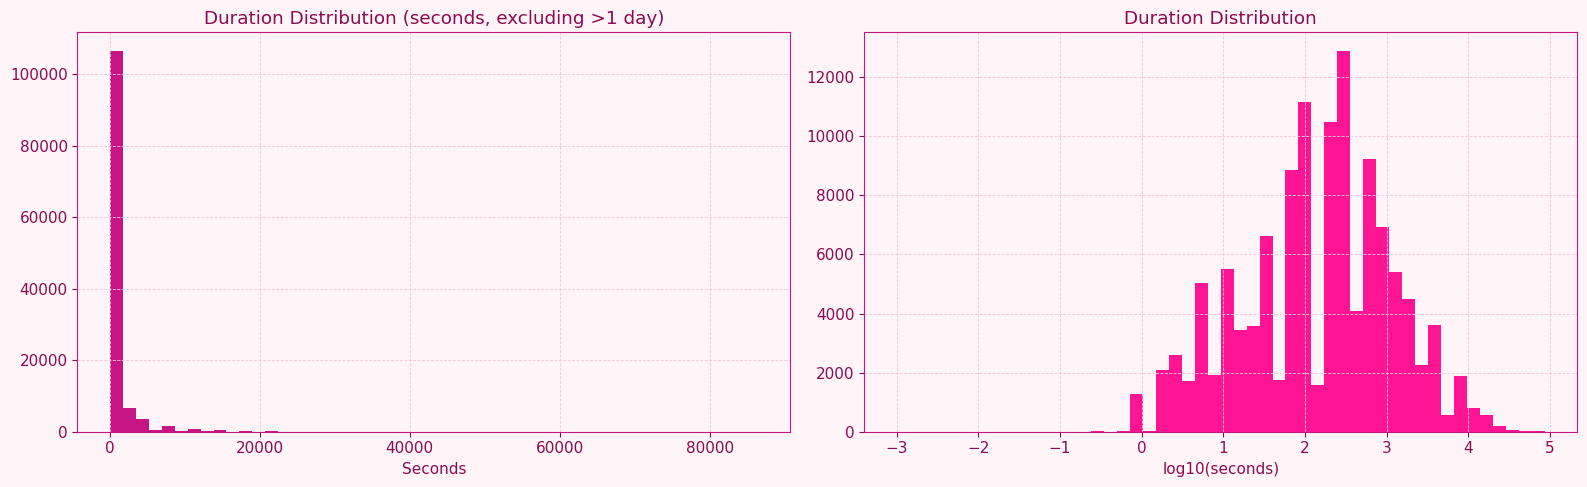

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_data = data_1[(data_1['duration_seconds'] > 0) & (~data_1['duration_extreme_flag'])]['duration_seconds']
axes[0].hist(plot_data, bins=50, color=PINK_PALETTE[2])
axes[0].set_title('Duration Distribution (seconds, excluding >1 day)')
axes[0].set_xlabel('Seconds')

axes[1].hist(np.log10(plot_data), bins=50, color=PINK_PALETTE[3])
axes[1].set_title('Duration Distribution')
axes[1].set_xlabel('log10(seconds)')

plt.tight_layout()
plt.show()

Evaluating the Overall frequency and Shape now

In [43]:
shape_counts = data_1['shape'].value_counts(dropna=False)
print("Shape Counts: ", shape_counts.head(10))

Shape Counts:  shape
light       28506
circle      15083
triangle    12607
other        9678
fireball     9678
unknown      9566
sphere       9175
disk         8338
NaN          6299
oval         6116
Name: count, dtype: int64


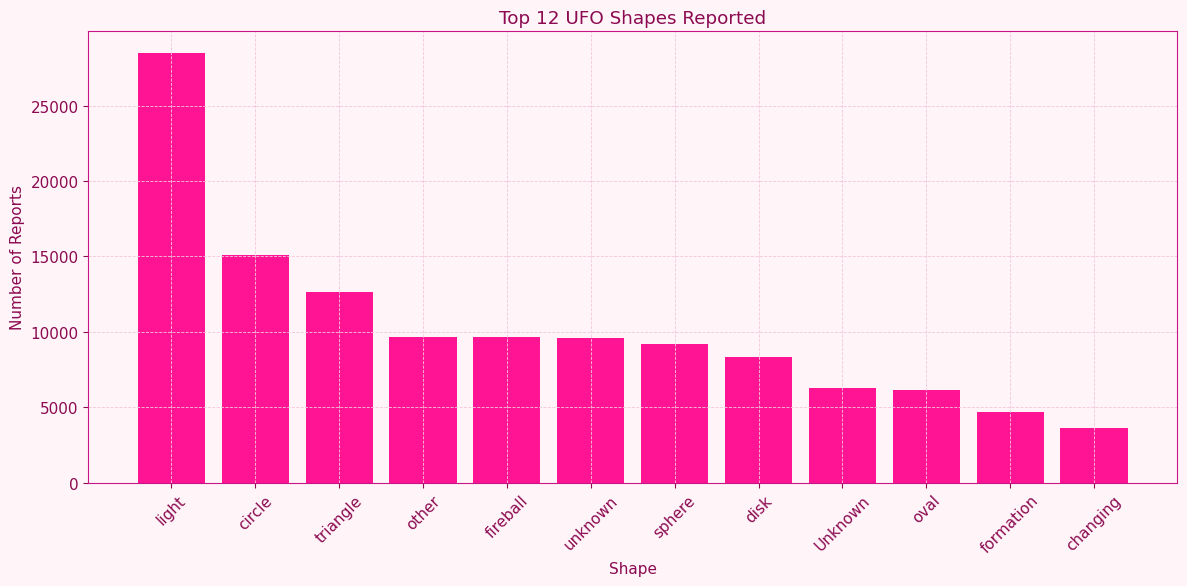

In [44]:
##visualizing the dumbness (quite honestly)
fig, ax = plt.subplots(figsize=(12, 6))
top_shapes = shape_counts.head(12)
top_shapes.index = top_shapes.index.fillna('Unknown').astype(str)

ax.bar(top_shapes.index, top_shapes.values, color=PINK_PALETTE[3])
ax.set_title('Top 12 UFO Shapes Reported')
ax.set_xlabel('Shape')
ax.set_ylabel('Number of Reports')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Also lets try seeing the shape with respect to hour of days ..maybe heatmap will be cool for this visualization.

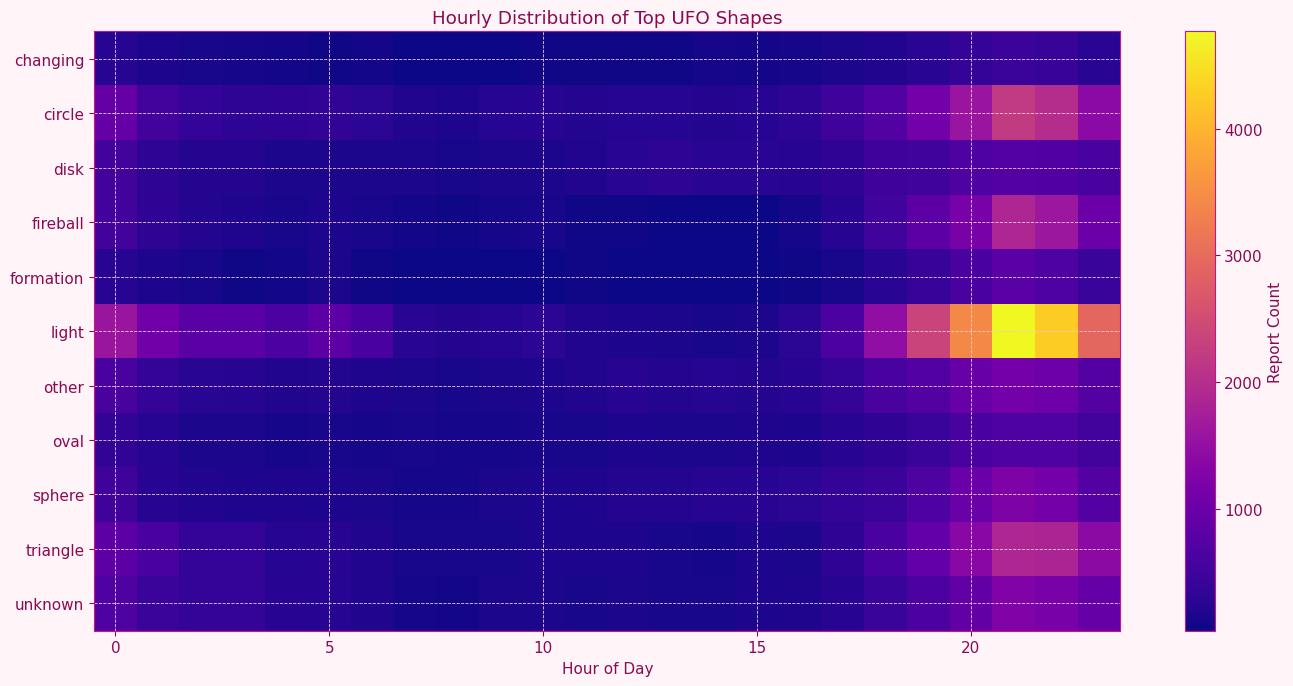

In [45]:
top_shape_names = shape_counts.dropna().head(12).index.tolist()
shape_hour = data_1[data_1['shape'].isin(top_shape_names)].groupby(['shape', 'hour']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(shape_hour, aspect='auto', cmap='plasma')
ax.set_yticks(range(len(shape_hour.index)))
ax.set_yticklabels(shape_hour.index)
ax.set_xlabel('Hour of Day')
ax.set_title('Hourly Distribution of Top UFO Shapes')

plt.colorbar(im, ax=ax, label='Report Count')
plt.tight_layout()
plt.show()


In [46]:
shape_duration = data_1[data_1['shape'].isin(top_shape_names) & (~data_1['duration_extreme_flag'])].groupby('shape')['duration_seconds'].median().sort_values(ascending=False)
print(shape_duration)

shape
changing     450.0
disk         210.0
unknown      210.0
circle       180.0
formation    180.0
light        180.0
other        180.0
oval         180.0
sphere       180.0
triangle     180.0
fireball     120.0
Name: duration_seconds, dtype: float64


Now ig lets check the summary analysis too

In [47]:
data_1['summary_length'] = data_1['summary'].dropna().apply(lambda x: len(str(x).split()))
print(data_1['summary_length'].describe())

count    141189.000000
mean         14.333029
std           7.524566
min           1.000000
25%           8.000000
50%          13.000000
75%          20.000000
max          36.000000
Name: summary_length, dtype: float64


Basically trying to see how much words a person have used to give the review of their observations 

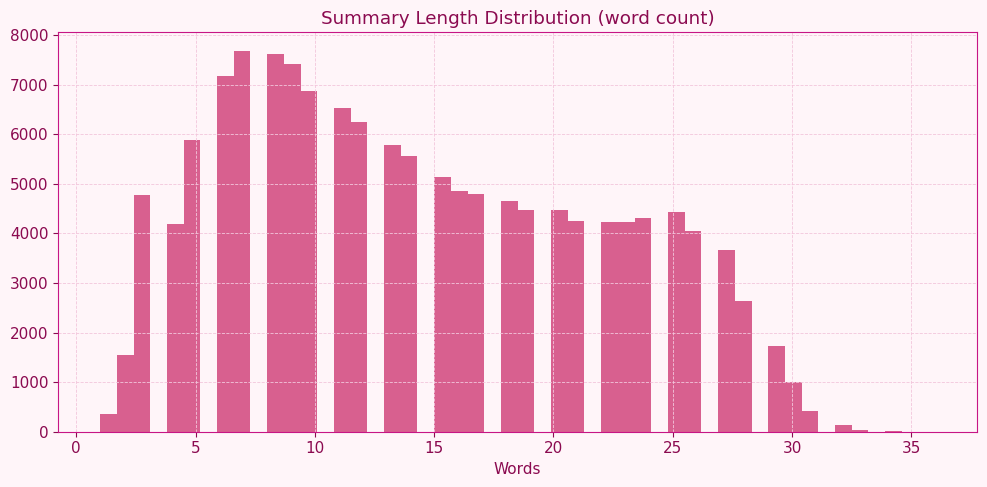

In [48]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(data_1['summary_length'].dropna(), bins=50, color=PINK_PALETTE[4])
ax.set_title('Summary Length Distribution (word count)')
ax.set_xlabel('Words')

plt.tight_layout()
plt.show()

Checking the words the people use to describe what they saw - trust me they all were high when they saw these things ....cause wdym CIGAR SHAPED???

In [49]:
from collections import Counter

stopwords = set(['the','a','an','and','or','of','to','in','on','at','was','it',
                  'i','my','we','with','for','then','that','this','saw','object'])

all_words = []
for s in data_1['summary'].dropna().astype(str):
    words = re.findall(r'\b[a-z]+\b', s.lower())
    all_words.extend([w for w in words if w not in stopwords and len(w) > 2])

word_freq = Counter(all_words).most_common(20)
print(word_freq)

[('lights', 32183), ('light', 31582), ('sky', 30766), ('bright', 23415), ('over', 21549), ('moving', 16722), ('white', 15108), ('orange', 14780), ('red', 14077), ('from', 13133), ('shaped', 11306), ('like', 10604), ('very', 10208), ('seen', 9636), ('flying', 9267), ('craft', 9045), ('ufo', 9020), ('two', 7575), ('large', 7278), ('objects', 7127)]


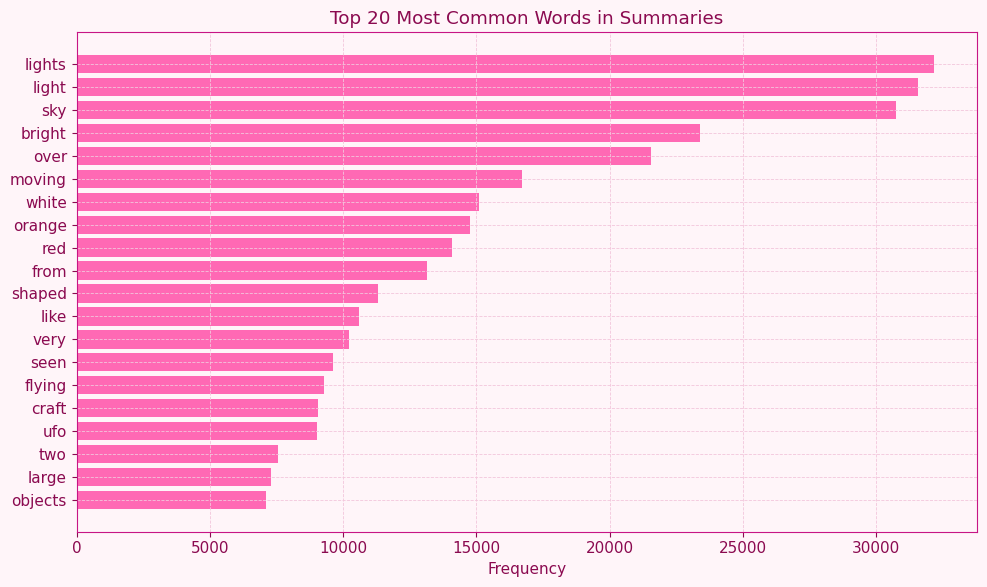

In [50]:
fig, ax = plt.subplots(figsize=(10,6))
words, counts = zip(*word_freq)
ax.barh(words[::-1], counts[::-1], color=PINK_PALETTE[0])
ax.set_title('Top 20 Most Common Words in Summaries')
ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

Checking for still any missing thingies

In [51]:
cols_to_check = ['state','city','shape','duration','city_latitude','city_longitude','country','summary']
missing_matrix = data_1[cols_to_check].isna().astype(int)

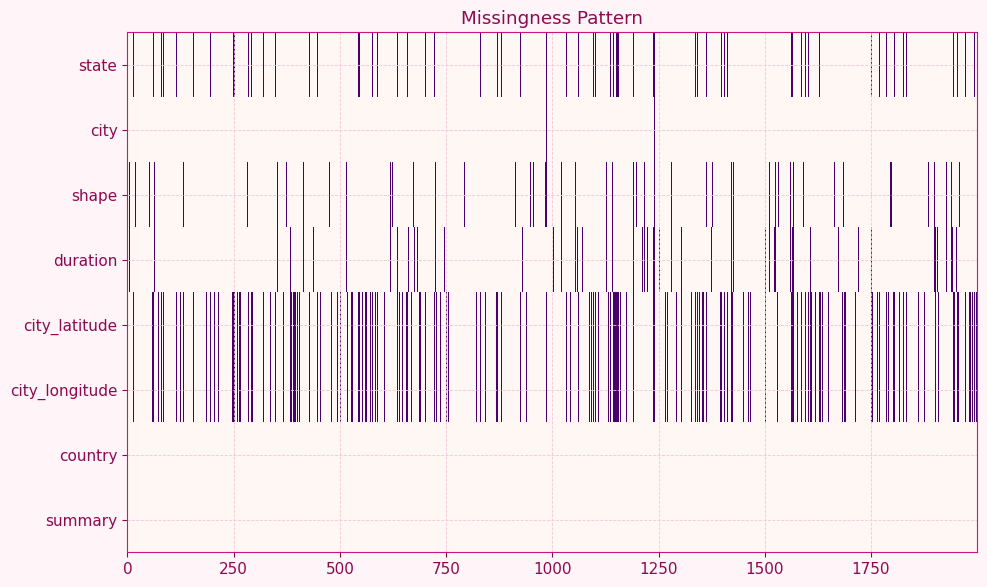

In [52]:
fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(missing_matrix.sample(2000, random_state=1).T, aspect='auto', cmap='RdPu', interpolation='none')
ax.set_yticks(range(len(cols_to_check)))
ax.set_yticklabels(cols_to_check)
ax.set_title('Missingness Pattern')
plt.tight_layout()
plt.show()

Proper details of the things that are missing from the each cols

In [53]:
missing_corr = missing_matrix.corr()
print(missing_corr.round(2))

                state  city  shape  duration  city_latitude  city_longitude  \
state            1.00  0.10   0.01      0.02           0.57            0.57   
city             0.10  1.00   0.08      0.09           0.12            0.12   
shape            0.01  0.08   1.00      0.43           0.01            0.01   
duration         0.02  0.09   0.43      1.00           0.01            0.01   
city_latitude    0.57  0.12   0.01      0.01           1.00            1.00   
city_longitude   0.57  0.12   0.01      0.01           1.00            1.00   
country          0.17  0.37   0.08      0.08           0.10            0.10   
summary         -0.00  0.01   0.06      0.03           0.00            0.00   

                country  summary  
state              0.17    -0.00  
city               0.37     0.01  
shape              0.08     0.06  
duration           0.08     0.03  
city_latitude      0.10     0.00  
city_longitude     0.10     0.00  
country            1.00    -0.00  
summary 

In [54]:
%pip install astral --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from astral import LocationInfo, moon
from astral.sun import sun

In [56]:
unique_dates = data_1['date_time_updated'].dt.date.dropna().unique()
print(f"Unique dates to compute: {len(unique_dates)}")

moon_phase_lookup = {d: moon.phase(d) for d in unique_dates}
data_1['moon_phase_value'] = data_1['date_time_updated'].dt.date.map(moon_phase_lookup)

def categorize_moon_phase(val):
    if pd.isna(val): return np.nan
    if val < 3.5 or val >= 24.5: return 'New Moon'
    elif val < 10.5: return 'Waxing'
    elif val < 17.5: return 'Full Moon'
    else: return 'Waning'

data_1['moon_phase_category'] = data_1['moon_phase_value'].apply(categorize_moon_phase)
print(data_1['moon_phase_category'].value_counts())

Unique dates to compute: 13349
moon_phase_category
Waning       36149
New Moon     35549
Waxing       34237
Full Moon    32666
Name: count, dtype: int64


In [57]:
data_1['lat_round'] = data_1['city_latitude'].round(1)
data_1['lng_round'] = data_1['city_longitude'].round(1)

geo_rows = data_1.dropna(subset=['lat_round', 'lng_round', 'date_time_updated'])
unique_combos = geo_rows[['lat_round', 'lng_round']].assign(
    date=geo_rows['date_time_updated'].dt.date
).drop_duplicates()

print(f"Unique lat/lng/date combos to compute: {len(unique_combos)}")

def get_sun_times(lat, lng, date):
    try:
        loc = LocationInfo(latitude=lat, longitude=lng)
        s = sun(loc.observer, date=date)
        return s['dawn'], s['sunrise'], s['sunset'], s['dusk']
    except Exception:
        return None, None, None, None

sun_lookup = {}
for _, row in unique_combos.iterrows():
    key = (row['lat_round'], row['lng_round'], row['date'])
    sun_lookup[key] = get_sun_times(row['lat_round'], row['lng_round'], row['date'])

print("Sun time lookup built:", len(sun_lookup))

Unique lat/lng/date combos to compute: 108753
Sun time lookup built: 108753


In [58]:
def classify_daylight(row):
    key = (row['lat_round'], row['lng_round'],
           row['date_time_updated'].date() if pd.notna(row['date_time_updated']) else None)
    times = sun_lookup.get(key)
    if times is None or times[0] is None:
        return np.nan
    dawn, sunrise, sunset, dusk = times
    t = row['date_time_updated']
    if pd.isna(t):
        return np.nan
    t = t.tz_localize(dawn.tzinfo) if t.tzinfo is None else t
    if t < dawn or t > dusk:
        return 'Night'
    elif t < sunrise or t > sunset:
        return 'Twilight'
    else:
        return 'Day'

data_1['daylight_status'] = data_1.apply(classify_daylight, axis=1)
print(data_1['daylight_status'].value_counts())

daylight_status
Night       91876
Day         19960
Twilight     1333
Name: count, dtype: int64


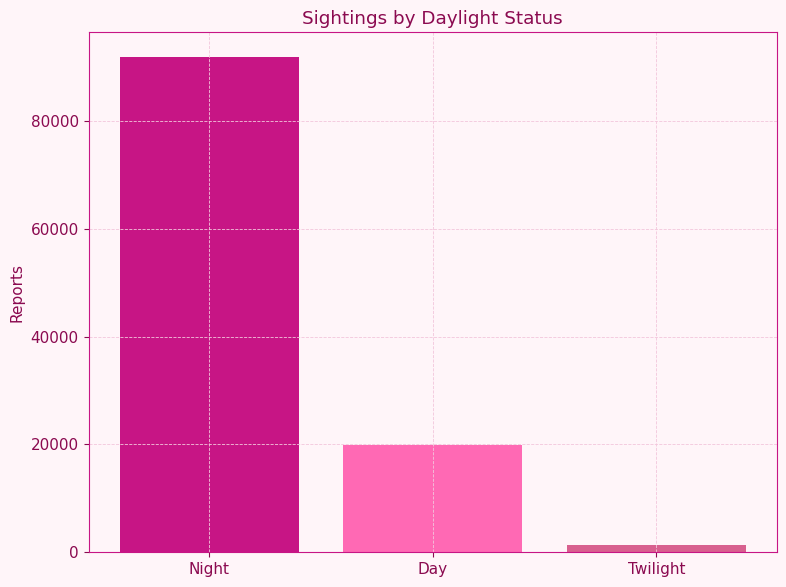

In [59]:
fig, ax = plt.subplots(figsize=(8,6))
daylight_counts = data_1['daylight_status'].value_counts()
ax.bar(daylight_counts.index, daylight_counts.values, color=[PINK_PALETTE[2], PINK_PALETTE[0], PINK_PALETTE[4]])
ax.set_title('Sightings by Daylight Status')
ax.set_ylabel('Reports')
plt.tight_layout()

plt.show()

In [60]:
moon_shape = data_1[data_1['daylight_status']=='Night'].groupby('moon_phase_category')['shape'].apply(lambda x: (x=='light').mean()*100)
print("Number of night sightings classified as 'light' shape, by moon phase:")
print(moon_shape)

Number of night sightings classified as 'light' shape, by moon phase:
moon_phase_category
Full Moon    20.114010
New Moon     21.178800
Waning       20.598892
Waxing       20.428343
Name: shape, dtype: float64


Notice a trend how they all are night time thingies and not day time...hah they are nuts please!!
Also moon brightness does not tell us anything about it wasay....they are within eachothers impact

In [61]:
%pip install meteostat --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import meteostat as ms
from datetime import date

test_point = ms.Point(40.7128, -74.0060)  # New York, as a test
START = date(2019, 6, 23)
END = date(2019, 6, 23)

stations = ms.stations.nearby(test_point, limit=4)
ts = ms.daily(stations, START, END)
test_df = ms.interpolate(ts, test_point).fetch()

print(test_df)

            temp  tmin  tmax  rhum  prcp  snwd  wspd    pres  cldc
time                                                              
2019-06-23  24.7  19.4  30.6    46   0.0     0   9.3  1014.5     0


# Starting the Training And Preparing of Model:

In [65]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

we are basically creating a Spatial Grid and counting sightings per month

In [66]:
GRID_SIZE = 0.5
geo_data = data_1.dropna(subset=['city_latitude', 'city_longitude', 'date_time_updated']).copy()
geo_data['grid_lat'] = (geo_data['city_latitude'] // GRID_SIZE) * GRID_SIZE
geo_data['grid_lng'] = (geo_data['city_longitude'] // GRID_SIZE) * GRID_SIZE
geo_data['month'] = geo_data['date_time_updated'].dt.month

grid_counts = geo_data.groupby(['grid_lat', 'grid_lng', 'month']).size().reset_index(name='sighting_count')
print(f"Grid-cell-month combos: {len(grid_counts)}")

Grid-cell-month combos: 19408


Merging the things together here

In [ ]:
cities = pd.read_csv('cities15000.txt', sep='\t', header=None, low_memory=False)
cities.columns = ['geonameid','name','asciiname','alternatenames','latitude','longitude',
                   'feature_class','feature_code','country_code','cc2','admin1_code','admin2_code',
                   'admin3_code','admin4_code','population','elevation','dem','timezone','modification_date']

cities['grid_lat'] = (cities['latitude'] // GRID_SIZE) * GRID_SIZE
cities['grid_lng'] = (cities['longitude'] // GRID_SIZE) * GRID_SIZE
grid_population = cities.groupby(['grid_lat','grid_lng'])['population'].sum().reset_index()
grid_population.columns = ['grid_lat','grid_lng','total_population']

grid_env_features = geo_data.groupby(['grid_lat','grid_lng','month']).agg(avg_moon_phase_value=('moon_phase_value','mean'),pct_night=('daylight_status', lambda x: (x=='Night').mean())).reset_index()

model_data = grid_counts.merge(grid_population, on=['grid_lat','grid_lng'], how='left')
model_data = model_data.merge(grid_env_features, on=['grid_lat','grid_lng','month'], how='left')
print(f"model_data shape: {model_data.shape}")
print(model_data.isnull().sum())

model_data shape: (19408, 7)
grid_lat                    0
grid_lng                    0
month                       0
sighting_count              0
total_population        10094
avg_moon_phase_value        0
pct_night                   0
dtype: int64


dropping rows that we dont need for the training

In [70]:
model_data_clean = model_data.dropna(subset=['total_population','month','avg_moon_phase_value','pct_night','sighting_count'])
print(f"Rows used for modeling: {len(model_data_clean)} (out of {len(model_data)})")

Rows used for modeling: 9314 (out of 19408)


### We implemented Poisson Model to keep the track of count of the events happening in the same window

In [71]:

poisson_model = smf.glm(formula='sighting_count ~ total_population + C(month) + avg_moon_phase_value + pct_night',data=model_data_clean,family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         sighting_count   No. Observations:                 9314
Model:                            GLM   Df Residuals:                     9299
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -61809.
Date:                Fri, 10 Jul 2026   Deviance:                       90752.
Time:                        11:58:13   Pearson chi2:                 1.27e+05
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9633
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.8107 

In [72]:
print(f"Deviance: {poisson_model.deviance:.2f}")
print(f"Degrees of freedom: {poisson_model.df_resid}")
print(f"Dispersion ratio (deviance/df): {poisson_model.deviance / poisson_model.df_resid:.2f}")

Deviance: 90752.15
Degrees of freedom: 9299
Dispersion ratio (deviance/df): 9.76


#### Negative Binomial regression is the same idea as Poisson, but with one extra parameter (called the dispersion parameter, α) that lets variance be larger than the mean, instead of forcing them to be equal. 

In [73]:
nb_model = smf.glm(
    formula='sighting_count ~ total_population + C(month) + avg_moon_phase_value + pct_night',
    data=model_data_clean,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

c:\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:         sighting_count   No. Observations:                 9314
Model:                            GLM   Df Residuals:                     9299
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -29128.
Date:                Fri, 10 Jul 2026   Deviance:                       6544.7
Time:                        12:00:12   Pearson chi2:                 7.17e+03
No. Iterations:                    46   Pseudo R-squ. (CS):             0.3497
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.6068 

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train_data, test_data = train_test_split(model_data_clean, test_size=0.2, random_state=42)
print(f"Train rows: {len(train_data)}, Test rows: {len(test_data)}")

Train rows: 7451, Test rows: 1863


#### Refitting the Negative Binomial model...but only on the training portion this time


In [ ]:
nb_model_train = smf.glm(
    formula='sighting_count ~ total_population + C(month) + avg_moon_phase_value + pct_night',
    data=train_data,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_train.summary())

c:\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:         sighting_count   No. Observations:                 7451
Model:                            GLM   Df Residuals:                     7436
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23275.
Date:                Fri, 10 Jul 2026   Deviance:                       5237.0
Time:                        12:07:04   Pearson chi2:                 5.74e+03
No. Iterations:                    47   Pseudo R-squ. (CS):             0.3458
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.5975 

In [ ]:
test_predictions = nb_model_train.predict(test_data)

mae = mean_absolute_error(test_data['sighting_count'], test_predictions)
rmse = np.sqrt(mean_squared_error(test_data['sighting_count'], test_predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"\nAverage actual sighting_count in test set: {test_data['sighting_count'].mean():.2f}")

Mean Absolute Error (MAE): 8933.08
Root Mean Squared Error (RMSE): 322433.27

Average actual sighting_count in test set: 10.18


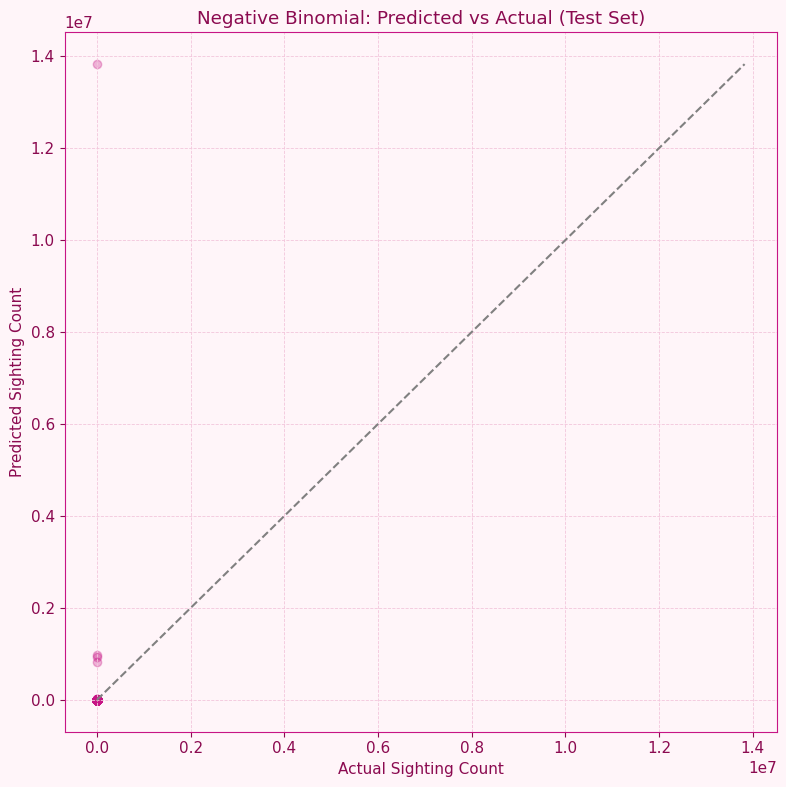

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(test_data['sighting_count'], test_predictions, alpha=0.3, color=PINK_PALETTE[2])
max_val = max(test_data['sighting_count'].max(), test_predictions.max())
ax.plot([0, max_val], [0, max_val], '--', color='gray')  # perfect-prediction reference line
ax.set_xlabel('Actual Sighting Count')
ax.set_ylabel('Predicted Sighting Count')
ax.set_title('Negative Binomial: Predicted vs Actual (Test Set)')
plt.tight_layout()
plt.savefig('nb_predicted_vs_actual.png', dpi=150)
plt.show()

In [ ]:
print(model_data_clean['total_population'].describe())
print()
print("Top 10 highest-population grid cells:")
print(model_data_clean.nlargest(10, 'total_population')[['grid_lat','grid_lng','month','total_population','sighting_count']])

count    9.314000e+03
mean     2.548949e+05
std      7.181062e+05
min      3.029000e+03
25%      2.952400e+04
50%      6.856000e+04
75%      1.926105e+05
max      1.147281e+07
Name: total_population, dtype: float64

Top 10 highest-population grid cells:
       grid_lat  grid_lng  month  total_population  sighting_count
11541      40.5     -74.5      1        11472812.0              56
11542      40.5     -74.5      2        11472812.0              49
11543      40.5     -74.5      3        11472812.0              54
11544      40.5     -74.5      4        11472812.0              51
11545      40.5     -74.5      5        11472812.0              51
11546      40.5     -74.5      6        11472812.0              63
11547      40.5     -74.5      7        11472812.0              94
11548      40.5     -74.5      8        11472812.0              88
11549      40.5     -74.5      9        11472812.0              81
11550      40.5     -74.5     10        11472812.0              54
       gr

#### Find the specific row that produced the extreme prediction


In [ ]:
test_data_with_preds = test_data.copy()
test_data_with_preds['predicted'] = test_predictions
print(test_data_with_preds.nlargest(3, 'predicted')[['grid_lat','grid_lng','month','total_population','sighting_count','predicted']])

       grid_lat  grid_lng  month  total_population  sighting_count  \
11546      40.5     -74.5      6        11472812.0              63   
11560      40.5     -74.0      8         9319474.0             149   
11561      40.5     -74.0      9         9319474.0             151   

          predicted  
11546  1.382632e+07  
11560  9.696305e+05  
11561  9.415612e+05  


##### what cities did our GeoNames aggregation sum into that grid cell?


In [ ]:
outlier_row = test_data_with_preds.nlargest(1, 'predicted').iloc[0]
print(f"Outlier grid cell: lat={outlier_row['grid_lat']}, lng={outlier_row['grid_lng']}")
matching_cities = cities[(cities['grid_lat']==outlier_row['grid_lat']) & (cities['grid_lng']==outlier_row['grid_lng'])]
print(matching_cities[['name','population']].sort_values('population', ascending=False))
print(f"\nSum: {matching_cities['population'].sum():,}")

Outlier grid cell: lat=40.5, lng=-74.5
                  name  population
21407    New York City     8175133
21444    Staten Island      468730
21275           Newark      277140
21259      Jersey City      247597
21286         Paterson      146199
...                ...         ...
21274      New Milford       16341
21298         Secaucus       16264
21267          Madison       15845
21276  North Arlington       15392
21248            Fords       15187

[63 rows x 2 columns]

Sum: 11,472,812


Training again after cleaning and fixing things:

In [85]:
model_data_clean = model_data_clean.copy()
model_data_clean['log_population'] = np.log1p(model_data_clean['total_population'])

train_data, test_data = train_test_split(model_data_clean, test_size=0.2, random_state=42)

nb_model_train = smf.glm(
    formula='sighting_count ~ log_population + C(month) + avg_moon_phase_value + pct_night',
    data=train_data,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_train.summary())

test_predictions = nb_model_train.predict(test_data)
mae = mean_absolute_error(test_data['sighting_count'], test_predictions)
rmse = np.sqrt(mean_squared_error(test_data['sighting_count'], test_predictions))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, Avg actual: {test_data['sighting_count'].mean():.2f}")

c:\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:         sighting_count   No. Observations:                 7451
Model:                            GLM   Df Residuals:                     7436
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22391.
Date:                Fri, 10 Jul 2026   Deviance:                       3469.0
Time:                        16:09:21   Pearson chi2:                 4.13e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4840
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.9321 

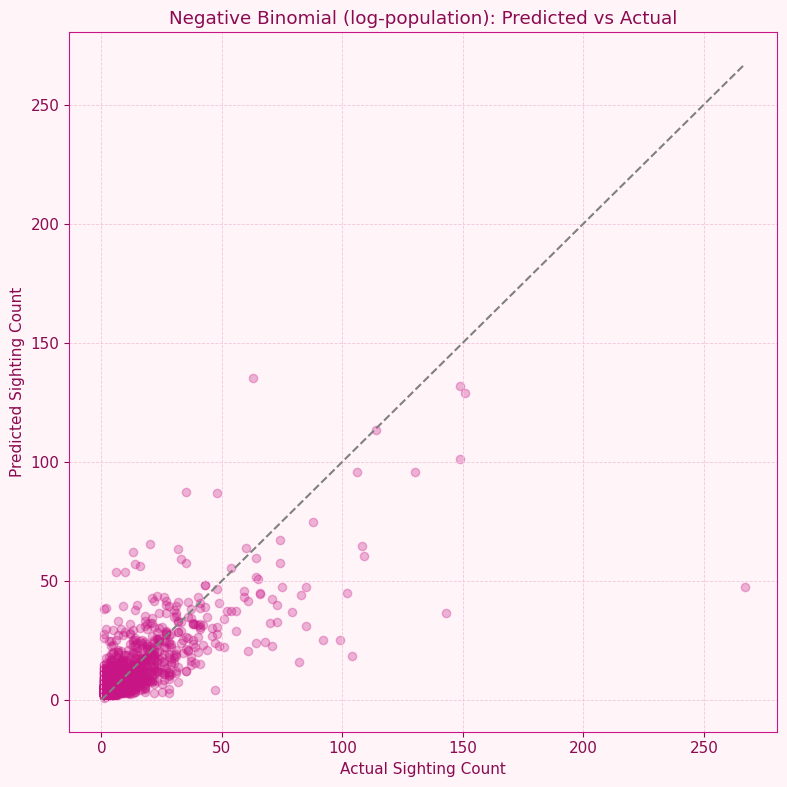

In [86]:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(test_data['sighting_count'], test_predictions, alpha=0.3, color=PINK_PALETTE[2])
max_val = max(test_data['sighting_count'].max(), test_predictions.max())
ax.plot([0, max_val], [0, max_val], '--', color='gray')
ax.set_xlabel('Actual Sighting Count')
ax.set_ylabel('Predicted Sighting Count')
ax.set_title('Negative Binomial (log-population): Predicted vs Actual')
plt.tight_layout()

plt.show()

Predict expected UFO sighting count for a given location and month.


In [87]:
def predict_sightings(lat, lng, month, moon_phase_value=14, pct_night=0.8):
    grid_lat = (lat // GRID_SIZE) * GRID_SIZE
    grid_lng = (lng // GRID_SIZE) * GRID_SIZE
    
    pop_row = grid_population[(grid_population['grid_lat']==grid_lat) & (grid_population['grid_lng']==grid_lng)]
    if pop_row.empty:
        return None  
    
    log_pop = np.log1p(pop_row['total_population'].values[0])
    
    input_df = pd.DataFrame({
        'log_population': [log_pop],
        'month': [month],
        'avg_moon_phase_value': [moon_phase_value],
        'pct_night': [pct_night]
    })
    
    prediction = nb_model_train.predict(input_df)
    return prediction.values[0]

#### Predict for Phoenix, Arizona, in July


In [83]:
result = predict_sightings(lat=33.4484, lng=-112.0740, month=7)
print(f"Predicted sightings: {result:.1f}")

Predicted sightings: 50.5


#### Predict for Phoenix, Arizona, in Feburary


In [84]:
result = predict_sightings(lat=33.4484, lng=-112.0740, month=2)
print(f"Predicted sightings: {result:.1f}")

Predicted sightings: 28.7


Using visual aid showing why the difference in number - cause rate of sightings differ at both months

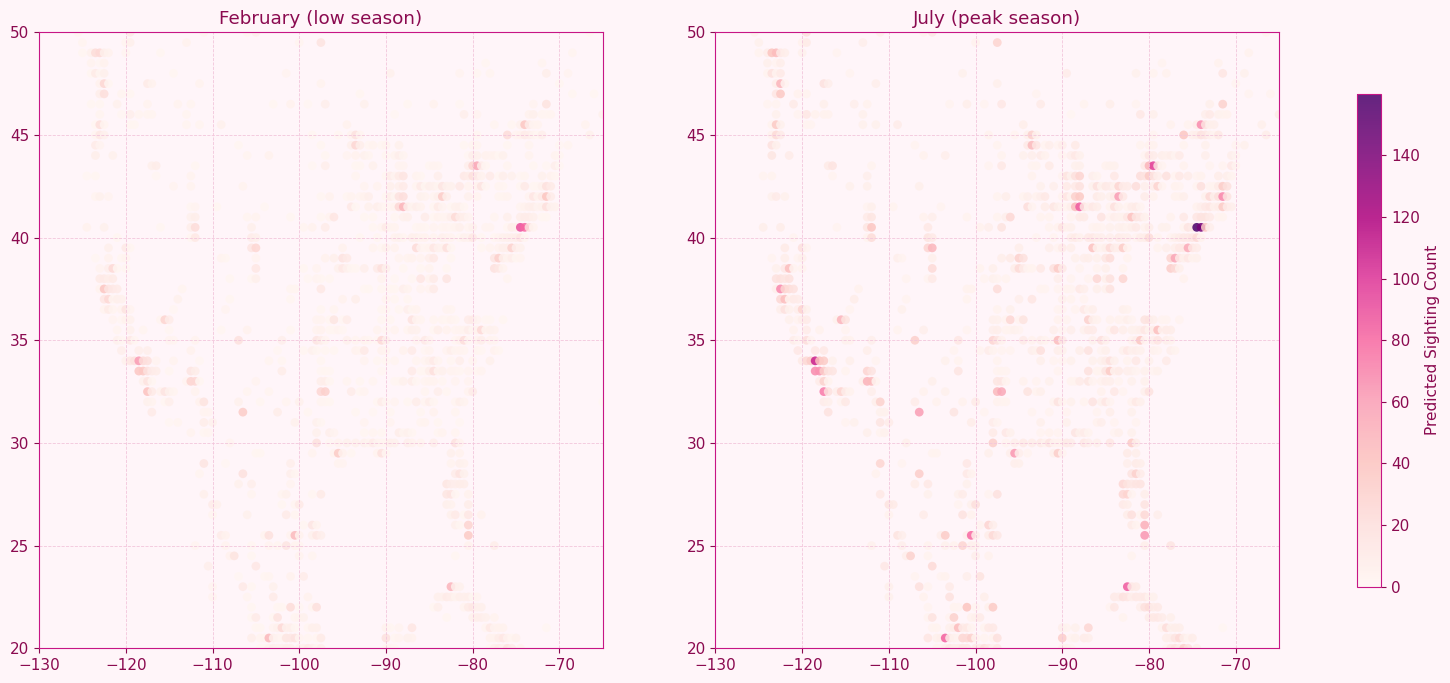

In [91]:
usa_grid_feb = usa_grid.copy()
usa_grid_feb['month'] = 2
usa_grid_feb['predicted_count'] = nb_model_train.predict(usa_grid_feb[['log_population','month','avg_moon_phase_value','pct_night']])

fig, axes = plt.subplots(1, 2, figsize=(20,8))
for ax, data, title in zip(axes, [usa_grid_feb, usa_grid], ['February (low season)', 'July (peak season)']):
    sc = ax.scatter(data['grid_lng'], data['grid_lat'], c=data['predicted_count'], cmap='RdPu', s=40, alpha=0.85, edgecolors='none', vmin=0, vmax=usa_grid['predicted_count'].max())
    ax.set_xlim(-130, -65)
    ax.set_ylim(20, 50)
    ax.set_title(title)
plt.colorbar(sc, ax=axes, label='Predicted Sighting Count', shrink=0.8)
plt.show()